In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from scipy import stats
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

In [4]:
# 그래프 크기와 재현성 설정
plt.rcParams["figure.figsize"] = (8, 5)
np.random.seed(42)

In [5]:
# 한글깨짐 해결, 원인:디폴트 영문글꼴==>한글글꼴
import matplotlib.pyplot as plt
import platform
if platform.system() == 'Windows': # W:대문자
    plt.rcParams['font.family'] = 'Malgun Gothic' # M,G:대문자, 중간에 스페이스 한칸
elif platform.system() == 'Darwin': # 맥OS, D:대문자
    plt.rcParams['font.family'] = 'AppleGothic'
else: # 리눅스
    plt.rcParams['font.family'] = 'NanumGothic'
# -(마이너스 기호) 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

In [6]:
# wine 데이터셋 불러오기
wine = load_wine(as_frame=True)
# DataFrame으로 복사
df = wine.frame.copy()
df

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0,2
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0,2
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0,2
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0,2


In [7]:
# 데이터 크기와 컬럼 확인
print("데이터 크기:", df.shape)
print("컬럼 목록:")
print(df.columns.tolist())

데이터 크기: (178, 14)
컬럼 목록:
['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline', 'target']


In [8]:
# 결측치와 타입 확인
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  targe

In [9]:
# 기초 통계량 확인
df.describe().T

,count,mean,std,min,25%,50%,75%,max
alcohol,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
malic_acid,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
ash,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
alcalinity_of_ash,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
magnesium,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
total_phenols,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
flavanoids,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
nonflavanoid_phenols,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
proanthocyanins,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58
color_intensity,178.0,5.058090,2.318286,1.28,3.2200,4.690,6.2000,13.00


In [10]:
# target은 와인 종류(0, 1, 2)
print("target 고유값:", df["target"].unique())
print("클래스 이름:", wine.target_names)

target 고유값: [0 1 2]
클래스 이름: ['class_0' 'class_1' 'class_2']


In [11]:
# 클래스별 개수 확인
df["target"].value_counts().sort_index()

target
0    59
1    71
2    48
Name: count, dtype: int64

In [12]:
# target을 제외한 수치형 컬럼 목록
numeric_cols = df.columns.drop("target").tolist()

print("수치형 변수 개수:", len(numeric_cols))
print(numeric_cols)

수치형 변수 개수: 13
['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']


In [13]:
# 수치형 변수끼리 상관계수 계산
corr = df[numeric_cols].corr()

corr

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
alcohol,1.000000,0.094397,0.211545,-0.310235,0.270798,0.289101,0.236815,-0.155929,0.136698,0.546364,-0.071747,0.072343,0.643720
malic_acid,0.094397,1.000000,0.164045,0.288500,-0.054575,-0.335167,-0.411007,0.292977,-0.220746,0.248985,-0.561296,-0.368710,-0.192011
ash,0.211545,0.164045,1.000000,0.443367,0.286587,0.128980,0.115077,0.186230,0.009652,0.258887,-0.074667,0.003911,0.223626
alcalinity_of_ash,-0.310235,0.288500,0.443367,1.000000,-0.083333,-0.321113,-0.351370,0.361922,-0.197327,0.018732,-0.273955,-0.276769,-0.440597
magnesium,0.270798,-0.054575,0.286587,-0.083333,1.000000,0.214401,0.195784,-0.256294,0.236441,0.199950,0.055398,0.066004,0.393351
total_phenols,0.289101,-0.335167,0.128980,-0.321113,0.214401,1.000000,0.864564,-0.449935,0.612413,-0.055136,0.433681,0.699949,0.498115
flavanoids,0.236815,-0.411007,0.115077,-0.351370,0.195784,0.864564,1.000000,-0.537900,0.652692,-0.172379,0.543479,0.787194,0.494193
nonflavanoid_phenols,-0.155929,0.292977,0.186230,0.361922,-0.256294,-0.449935,-0.537900,1.000000,-0.365845,0.139057,-0.262640,-0.503270,-0.311385
proanthocyanins,0.136698,-0.220746,0.009652,-0.197327,0.236441,0.612413,0.652692,-0.365845,1.000000,-0.025250,0.295544,0.519067,0.330417
color_intensity,0.546364,0.248985,0.258887,0.018732,0.199950,-0.055136,-0.172379,0.139057,-0.025250,1.000000,-0.521813,-0.428815,0.316100


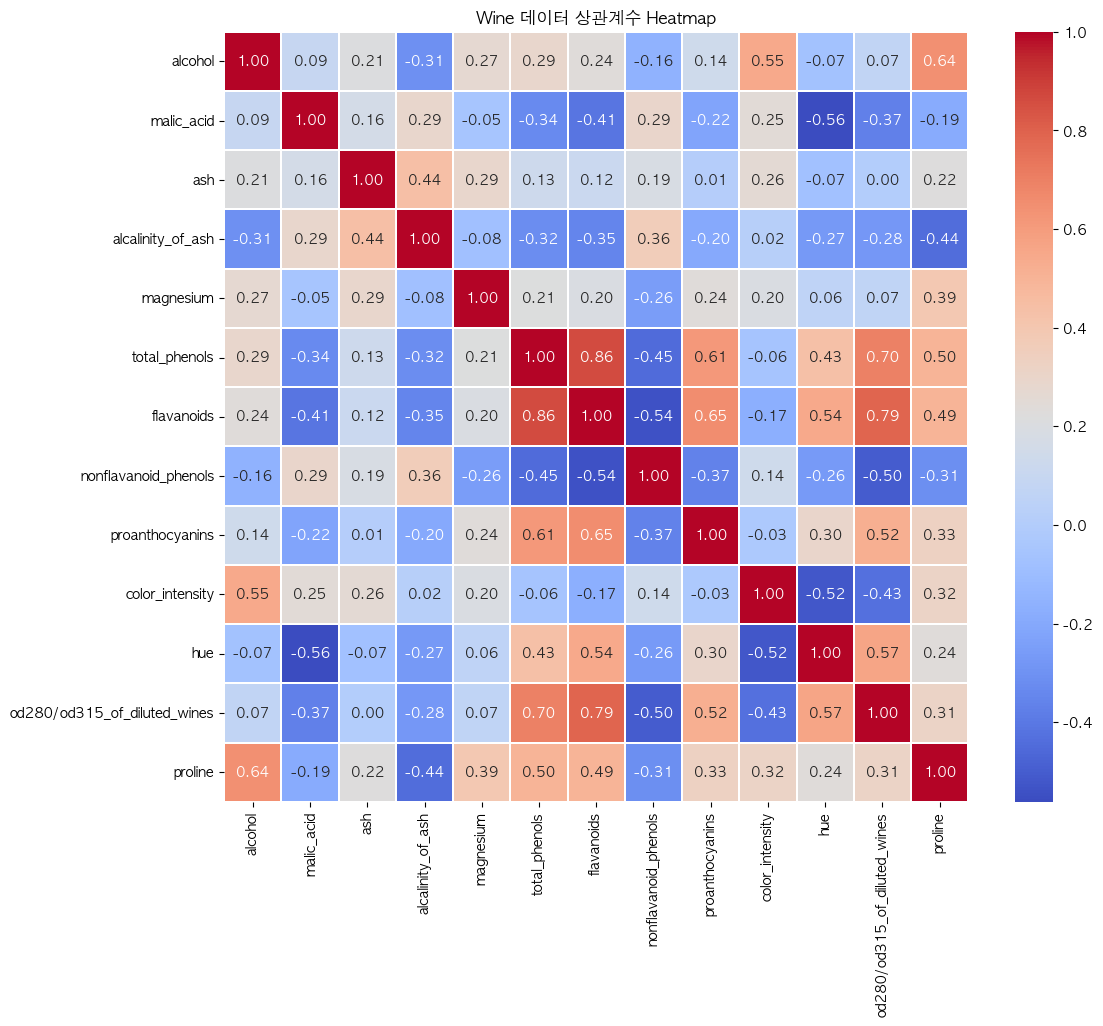

In [14]:
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.1)
plt.title("Wine 데이터 상관계수 Heatmap")
plt.show()

In [15]:
# 1) 상관계수 절댓값 계산
corr_abs = corr.abs()

# 2) 상관계수 표를 길게 펼치기
corr_pairs = corr_abs.stack().reset_index()

# 3) 컬럼 이름 정리
corr_pairs.columns = ["var1", "var2", "corr_value"]

# 4) 자기 자신과의 상관관계 제거
corr_pairs = corr_pairs[corr_pairs["var1"] != corr_pairs["var2"]]

# 5) (A, B)와 (B, A)를 같은 쌍으로 묶기
corr_pairs["pair"] = corr_pairs.apply(
    lambda row: tuple(sorted([row["var1"], row["var2"]])),
    axis=1
)

# 6) 중복 쌍 제거
corr_pairs = corr_pairs.drop_duplicates(subset="pair")

# 7) 상관계수 큰 순서대로 정렬
corr_pairs = corr_pairs.sort_values("corr_value", ascending=False)

# 8) 상위 10개 확인
corr_top10 = corr_pairs[["var1", "var2", "corr_value"]].head(10)

corr_top10

,var1,var2,corr_value
71,total_phenols,flavanoids,0.864564
89,flavanoids,od280/od315_of_diluted_wines,0.787194
76,total_phenols,od280/od315_of_diluted_wines,0.699949
86,flavanoids,proanthocyanins,0.652692
12,alcohol,proline,0.643720
73,total_phenols,proanthocyanins,0.612413
141,hue,od280/od315_of_diluted_wines,0.565468
23,malic_acid,hue,0.561296
9,alcohol,color_intensity,0.546364
88,flavanoids,hue,0.543479


In [16]:
# t-test는 두 그룹 비교이므로, target 0과 1만 골라서 진행합니다.
# target이 0, 1인 데이터만 선택
df_two_groups = df[df["target"].isin([0, 1])].copy()

df_two_groups["target"].value_counts().sort_index()

target
0    59
1    71
Name: count, dtype: int64

In [17]:
# 예시로 alcohol 변수 비교
test_variable = "alcohol"

group_0 = df_two_groups.loc[df_two_groups["target"] == 0, test_variable]
group_1 = df_two_groups.loc[df_two_groups["target"] == 1, test_variable]

print("target 0 평균:", group_0.mean())
print("target 1 평균:", group_1.mean())

target 0 평균: 13.744745762711865
target 1 평균: 12.278732394366195


In [18]:
t_stat, p_value = stats.ttest_ind(group_0, group_1, equal_var=False)

print("비교 변수:", test_variable)
print("t-statistic:", t_stat)
print("p-value:", p_value)

비교 변수: alcohol
t-statistic: 16.71133933365354
p-value: 5.92641233045226e-34


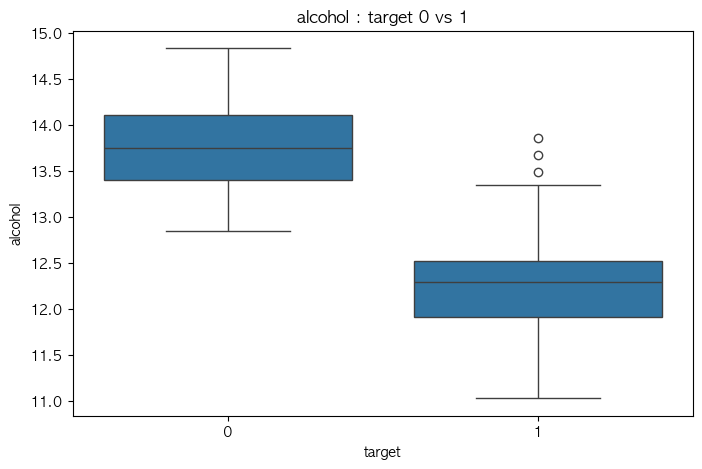

In [19]:
sns.boxplot(data=df_two_groups, x="target", y=test_variable)
plt.title(f"{test_variable} : target 0 vs 1")
plt.show()

In [20]:
ttest_result_list = []

for col in numeric_cols:
    group_0 = df_two_groups.loc[df_two_groups["target"] == 0, col]
    group_1 = df_two_groups.loc[df_two_groups["target"] == 1, col]
    # 두 그룹 평균 차이에 대해 t-test를 수행합니다.
    # equal_var=False는 두 그룹 분산이 같다고 가정하지 않는 Welch’s t-test입니다.
    # "이 두 그룹의 평균 차이가 우연이라고 보기 어려운가?"를 계산하는 것입니다.
    t_stat, p_value = stats.ttest_ind(group_0, group_1, equal_var=False)

    ttest_result_list.append({
        "variable": col,
        "mean_target_0": group_0.mean(),
        "mean_target_1": group_1.mean(),
        "t_stat": t_stat,
        "p_value": p_value
    })

ttest_result_df = pd.DataFrame(ttest_result_list)
ttest_result_df = ttest_result_df.sort_values("p_value")

ttest_result_df.head(10)
# target 0과 target 1은 여러 변수에서 평균 차이가 뚜렷하며, 특히 alcohol, proline, color_intensity 같은 변수는 두 그룹을 잘 구분하는 중요한 후보 변수다.

,variable,mean_target_0,mean_target_1,t_stat,p_value
0,alcohol,13.744746,12.278732,16.711339,5.926412e-34
12,proline,1115.711864,519.507042,17.357493,3.329627e-32
9,color_intensity,5.528305,3.086620,12.517304,1.403327e-22
6,flavanoids,2.982373,2.080845,9.157282,2.602682e-15
5,total_phenols,2.840169,2.258873,7.420649,1.889329e-11
3,alcalinity_of_ash,17.037288,20.238028,-6.183508,7.906619e-09
11,od280/od315_of_diluted_wines,3.157797,2.785352,4.961910,2.220787e-06
4,magnesium,106.338983,94.549296,4.886351,3.222382e-06
2,ash,2.455593,2.244789,4.418367,2.124341e-05
7,nonflavanoid_phenols,0.290000,0.363662,-4.255743,4.299033e-05


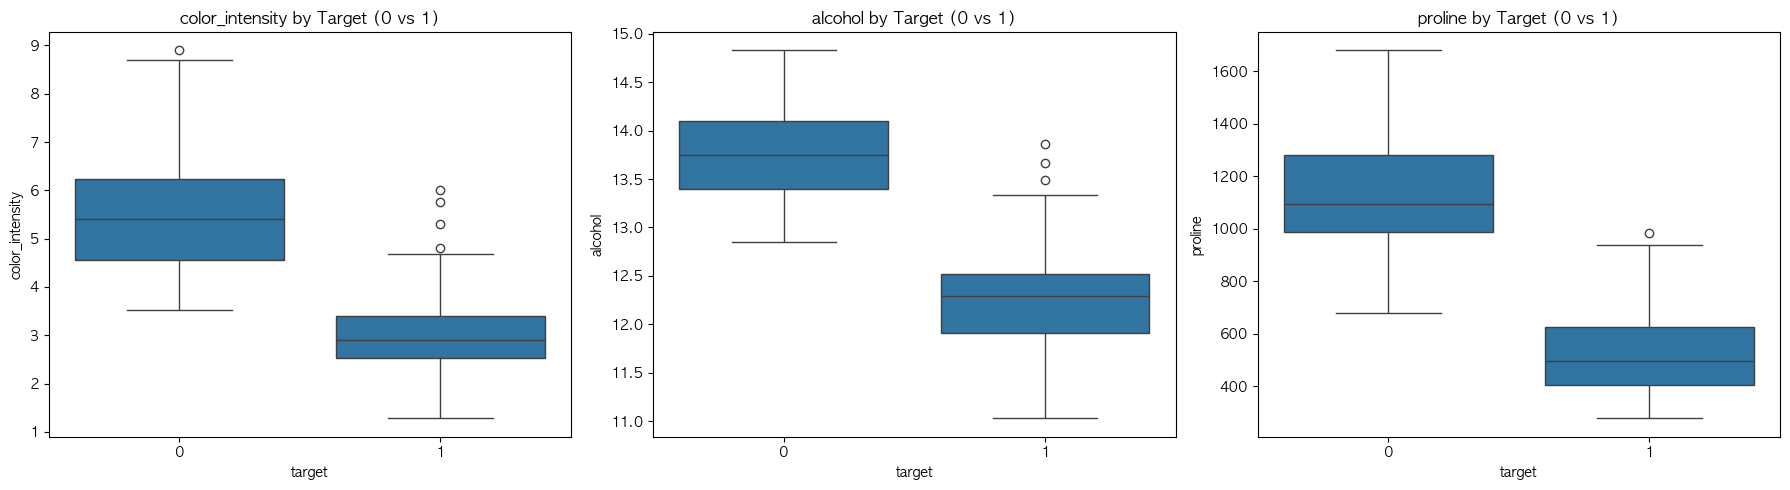

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(18, 5))

plt.subplot(131)
sns.boxplot(data=df_two_groups, x="target", y="color_intensity")
plt.title("color_intensity by Target (0 vs 1)")
plt.xlabel("target")
plt.ylabel("color_intensity")

plt.subplot(132)
sns.boxplot(data=df_two_groups, x="target", y="alcohol")
plt.title("alcohol by Target (0 vs 1)")
plt.xlabel("target")
plt.ylabel("alcohol")

plt.subplot(133)
sns.boxplot(data=df_two_groups, x="target", y="proline")
plt.title("proline by Target (0 vs 1)")
plt.xlabel("target")
plt.ylabel("proline")

plt.tight_layout()
plt.show()

In [22]:
# ANOVA는 3개 이상 그룹 평균 비교입니다. wine 데이터는 0, 1, 2 세 그룹이 있어 자연스럽습니다.

In [23]:
# 예시 변수 선택
anova_variable = "flavanoids"

for target_value in sorted(df["target"].unique()):
    mean_value = df.loc[df["target"] == target_value, anova_variable].mean()
    print(f"target {target_value} 평균: {mean_value:.3f}")

target 0 평균: 2.982
target 1 평균: 2.081
target 2 평균: 0.781


In [24]:
anova_groups = [
    df.loc[df["target"] == target_value, anova_variable]
    for target_value in sorted(df["target"].unique())
]

f_stat, p_value = stats.f_oneway(*anova_groups)

print("비교 변수:", anova_variable)
print("F-statistic:", f_stat)
print("p-value:", p_value)

비교 변수: flavanoids
F-statistic: 233.9258726815492
p-value: 3.5985858307137685e-50


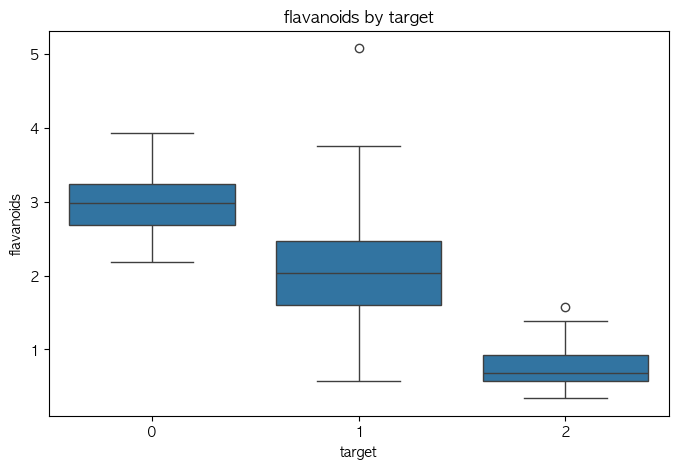

In [25]:
sns.boxplot(data=df, x="target", y=anova_variable)
plt.title(f"{anova_variable} by target")
plt.show()

In [26]:
anova_result_list = []

for col in numeric_cols:
    groups = [
        df.loc[df["target"] == target_value, col]
        for target_value in sorted(df["target"].unique())
    ]
    # stats.f_oneway()는 일원분산분석(One-way ANOVA) 를 수행하는 함수입니다.
    # 여러 그룹 평균이 모두 같은지 아니면 적어도 하나는 다른지를 확인합니다.
    # 앞에 *를 붙이면 리스트를 풀어서 넘김. stats.f_oneway(group0, group1, group2)
    f_stat, p_value = stats.f_oneway(*groups)
    # f_stat 해석법
    # F값이 크면 그룹 평균 차이가 큼. 그룹 안의 흔들림보다 그룹 사이 차이가 더 큼
    # 즉, 그룹이 서로 다를 가능성이 큼
    # F값이 작으면 그룹 평균 차이가 별로 없음. 또는 그룹 안에서 너무 많이 흔들림
    # 즉, 그룹 차이가 뚜렷하지 않음

    anova_result_list.append({
        "variable": col,
        "F_stat": f_stat,
        "p_value": p_value
    })

anova_result_df = pd.DataFrame(anova_result_list)
anova_result_df = anova_result_df.sort_values("p_value")

anova_result_df.head(10)

,variable,F_stat,p_value
6,flavanoids,233.925873,3.598586e-50
12,proline,207.920374,5.783168e-47
11,od280/od315_of_diluted_wines,189.972321,1.393105e-44
0,alcohol,135.077624,3.319504e-36
9,color_intensity,120.664018,1.162008e-33
10,hue,101.316795,5.917662e-30
5,total_phenols,93.733010,2.137670e-28
1,malic_acid,36.943425,4.127229e-14
3,alcalinity_of_ash,35.771637,9.444473e-14
8,proanthocyanins,30.271383,5.125359e-12


In [27]:
# PCA

In [28]:
# PCA에 사용할 입력값
X = df[numeric_cols].copy()

# 변수 단위 차이를 줄이기 위해 표준화
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [29]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("설명분산비율:", pca.explained_variance_ratio_)
print("누적 설명분산비율:", pca.explained_variance_ratio_.sum())

설명분산비율: [0.36198848 0.1920749 ]
누적 설명분산비율: 0.5540633835693527


In [30]:
pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["target"] = df["target"].values

pca_df.head()

,PC1,PC2,target
0,3.316751,1.443463,0
1,2.209465,-0.333393,0
2,2.516740,1.031151,0
3,3.757066,2.756372,0
4,1.008908,0.869831,0


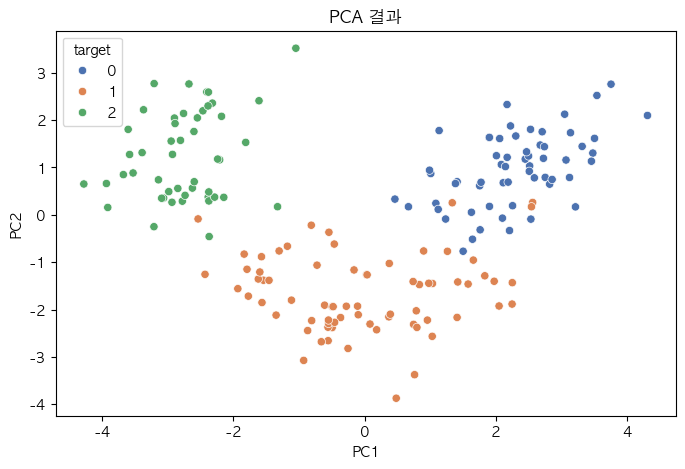

In [31]:
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="target", palette="deep")
plt.title("PCA 결과")
plt.show()

In [32]:
loading_df = pd.DataFrame(
    pca.components_.T,
    index=numeric_cols,
    columns=["PC1_loading", "PC2_loading"]
)

loading_df.sort_values("PC1_loading", ascending=False)
# 해석 포인트
# PCA는 많은 변수를 2개 축으로 압축해서 보는 도구
# 클래스가 어느 정도 나뉘는지 시각적으로 확인
# 적재값은 "어떤 변수가 축 형성에 많이 기여했는가" 참고용

,PC1_loading,PC2_loading
flavanoids,0.422934,-0.003360
total_phenols,0.394661,0.065040
od280/od315_of_diluted_wines,0.376167,-0.164496
proanthocyanins,0.313429,0.039302
hue,0.296715,-0.279235
proline,0.286752,0.364903
alcohol,0.144329,0.483652
magnesium,0.141992,0.299634
ash,-0.002051,0.316069
color_intensity,-0.088617,0.529996


In [33]:
# KMeans 적용

In [34]:
# 군집 수는 3으로 설정
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

cluster_labels = kmeans.fit_predict(X_scaled)

# 원본 데이터에 군집 결과 붙이기
df_cluster = df.copy()
df_cluster["cluster"] = cluster_labels

df_cluster.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target,cluster
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0,2
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0,2
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0,2
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0,2
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0,2


In [35]:
# 군집별 개수 확인
df_cluster["cluster"].value_counts().sort_index()

cluster
0    65
1    51
2    62
Name: count, dtype: int64

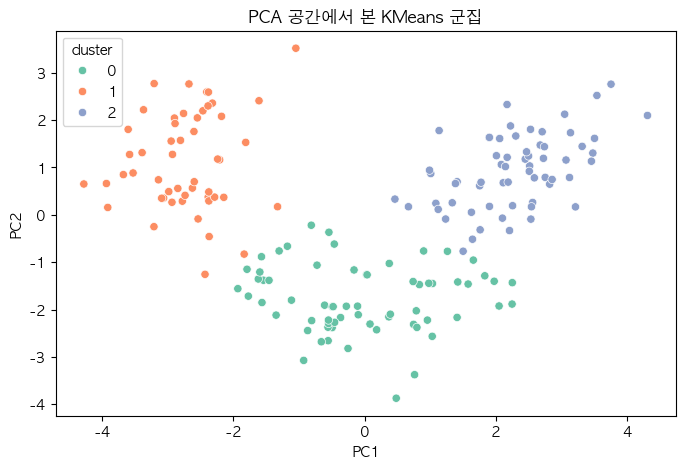

In [36]:
# PCA 공간에서 군집 시각화
cluster_plot_df = pca_df.copy()
cluster_plot_df["cluster"] = cluster_labels

sns.scatterplot(data=cluster_plot_df, x="PC1", y="PC2", hue="cluster", palette="Set2")
plt.title("PCA 공간에서 본 KMeans 군집")
plt.show()

In [37]:
# 실제 target과 cluster 비교
pd.crosstab(df_cluster["target"], df_cluster["cluster"])
# 해석 포인트
# 군집은 정답 없이 비슷한 패턴끼리 묶는 방법
# 오늘은 비교를 위해 군집 수를 3으로 설정
# 실제 target과 비슷하게 나뉘는지 참고 가능

cluster,0,1,2
target,,,
0,0,0,59
1,65,3,3
2,0,48,0


In [38]:
# Profiling

In [39]:
# 군집별 평균 비교
cluster_profile = df_cluster.groupby("cluster")[numeric_cols].mean().round(2)
cluster_profile

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
cluster,,,,,,,,,,,,,
0,12.25,1.90,2.23,20.06,92.74,2.25,2.05,0.36,1.62,2.97,1.06,2.80,510.17
1,13.13,3.31,2.42,21.24,98.67,1.68,0.82,0.45,1.15,7.23,0.69,1.70,619.06
2,13.68,2.00,2.47,17.46,107.97,2.85,3.00,0.29,1.92,5.45,1.07,3.16,1100.23


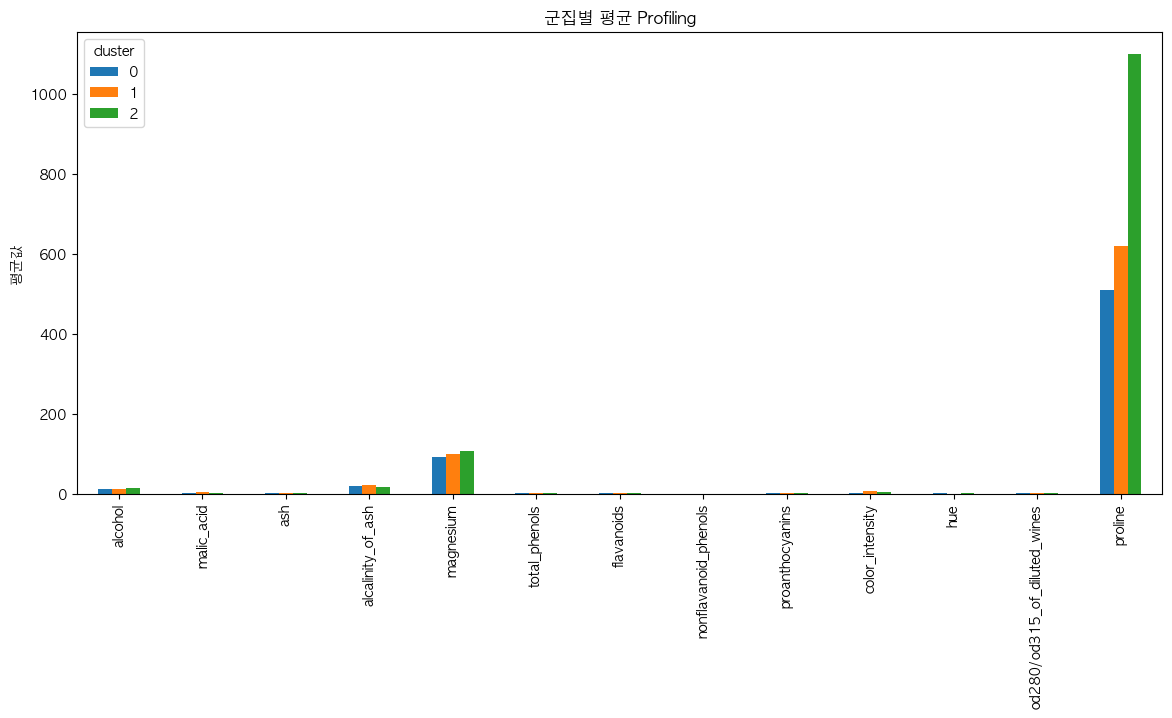

In [40]:
# 시각화
cluster_profile.T.plot(kind="bar", figsize=(14, 6))
plt.title("군집별 평균 Profiling")
plt.ylabel("평균값")
plt.show()

In [41]:
# 실제 target 기준 평균과 비교
target_profile = df.groupby("target")[numeric_cols].mean().round(2)
target_profile

# 해석 포인트
# 군집 번호 자체보다 군집의 특징이 중요
# 예: “고알코올/고플라보노이드형”, “상대적으로 안정형”처럼 해석
# profiling은 군집을 현업 언어로 바꾸는 단계

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
target,,,,,,,,,,,,,
0,13.74,2.01,2.46,17.04,106.34,2.84,2.98,0.29,1.90,5.53,1.06,3.16,1115.71
1,12.28,1.93,2.24,20.24,94.55,2.26,2.08,0.36,1.63,3.09,1.06,2.79,519.51
2,13.15,3.33,2.44,21.42,99.31,1.68,0.78,0.45,1.15,7.40,0.68,1.68,629.90


In [42]:
# 오늘 실습 요약 출력
print("오늘 확인한 내용")
print("1. 상관분석으로 변수 관계를 봤다")
print("2. t-test로 두 그룹 차이를 봤다")
print("3. ANOVA로 세 그룹 이상 차이를 봤다")
print("4. PCA로 구조를 압축했다")
print("5. 군집분석으로 비슷한 패턴을 묶었다")
print("6. Profiling으로 군집 특징을 해석했다")

오늘 확인한 내용
1. 상관분석으로 변수 관계를 봤다
2. t-test로 두 그룹 차이를 봤다
3. ANOVA로 세 그룹 이상 차이를 봤다
4. PCA로 구조를 압축했다
5. 군집분석으로 비슷한 패턴을 묶었다
6. Profiling으로 군집 특징을 해석했다


In [43]:
# 3일차 연결 질문
print("다음 시간 생각해볼 질문")
print("- 이 데이터를 분류 문제로 바꾸면 target은 무엇일까?")
print("- 어떤 변수들이 예측에 도움이 될까?")
print("- 어떤 지표를 중심으로 성능을 볼까?")

다음 시간 생각해볼 질문
- 이 데이터를 분류 문제로 바꾸면 target은 무엇일까?
- 어떤 변수들이 예측에 도움이 될까?
- 어떤 지표를 중심으로 성능을 볼까?


In [44]:
# end